### Exploratory analysis

Reading from file: results/meta-llama_Llama-3.1-8B-Instruct_scores-lora.jsonl

Successfully processed 76496 samples.

--- Base Model Score Analysis ---

Descriptive Statistics:
count    76496.000000
mean         0.059420
std          0.167762
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: score, dtype: float64

Score Frequency (Top 20):
score
0.0    62219
0.1     4815
0.2     3147
0.3     1863
0.4     1209
0.5      816
0.6      568
0.7      388
0.8      355
0.9      284
1.0      832
Name: count, dtype: int64


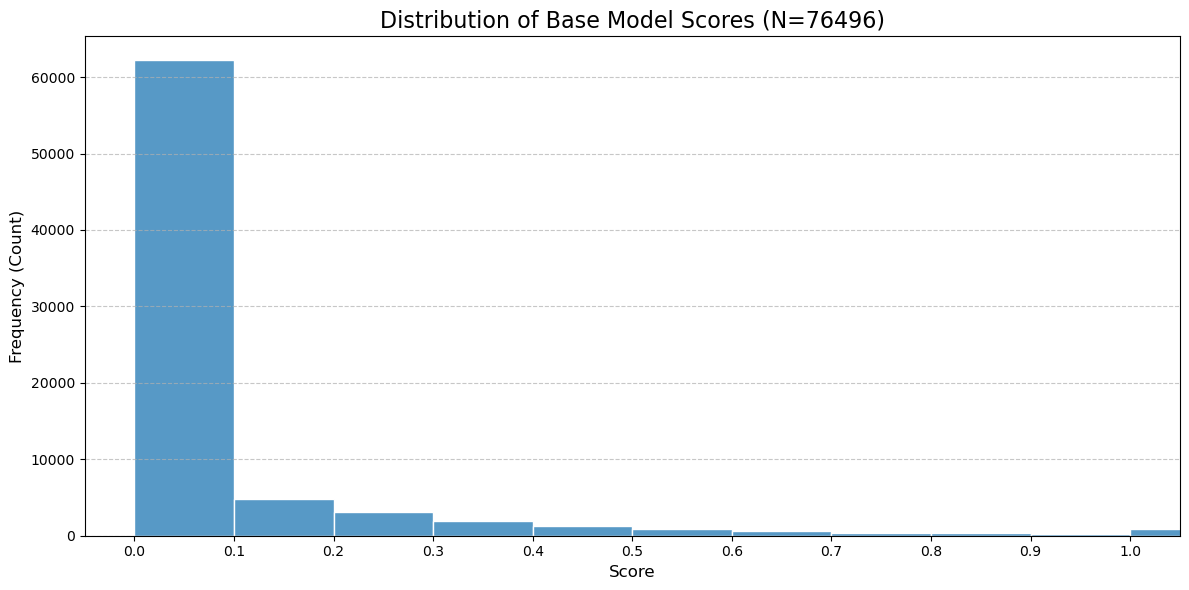

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# filename = "results/merged_all_adapters.jsonl"
filename = "results/meta-llama_Llama-3.1-8B-Instruct_scores-lora.jsonl"


base_model_scores = []
line_count = 0
error_count = 0

print(f"Reading from file: {filename}")

# Open the .jsonl file and read it line by line
try:
    with open(filename, 'r') as f:
        for line in f:
            line_count += 1
            try:
                # Remove any leading/trailing whitespace
                line_stripped = line.strip()
                
                # Skip empty lines
                if not line_stripped:
                    continue
                    
                # Load the JSON object from the line
                data = json.loads(line_stripped)
                
                # Extract the base model score and add it to our list
                score = data['base_eval']['score']
                base_model_scores.append(score)
                
            except json.JSONDecodeError:
                print(f"Warning: Could not decode JSON on line {line_count}. Skipping.")
                error_count += 1
            except KeyError:
                print(f"Warning: Missing 'base_eval' or 'score' key on line {line_count}. Skipping.")
                error_count += 1
            except Exception as e:
                print(f"Warning: An unexpected error occurred on line {line_count}: {e}. Skipping.")
                error_count += 1

    print(f"\nSuccessfully processed {len(base_model_scores)} samples.")
    if error_count > 0:
        print(f"Skipped {error_count} lines due to errors.")
    
    # Check if we actually found any data
    if not base_model_scores:
        print("Error: No valid base model scores were found in the file.")
    else:
        # Create a Pandas DataFrame for analysis
        df_base = pd.DataFrame(base_model_scores, columns=['score'])

        print("\n--- Base Model Score Analysis ---")

        # Show descriptive statistics
        print("\nDescriptive Statistics:")
        print(df_base['score'].describe())

        # Show the frequency of each score
        print("\nScore Frequency (Top 20):")
        print(df_base['score'].value_counts().sort_index().head(20))

        # --- Plot the Distribution ---
        plt.figure(figsize=(12, 6))
        
        # Use histplot for a good overview, especially with many values
        # We define discrete bins from 0 to 1 (11 bins for 0.0, 0.1, ..., 1.0)
        bins = [i/10 for i in range(12)] # [0.0, 0.1, ..., 1.0, 1.1]
        
        ax = sns.histplot(
            data=df_base, 
            x='score', 
            bins=bins, 
            kde=False, # Set to True if you want a density curve
            stat="count",
            edgecolor='white' # Add edge color for better bin separation
        )
        
        plt.title(f'Distribution of Base Model Scores (N={len(base_model_scores)})', fontsize=16)
        plt.xlabel('Score', fontsize=12)
        plt.ylabel('Frequency (Count)', fontsize=12)
        
        # Set x-axis limits and ticks to clearly show the 0.0-1.0 range
        ax.set_xlim(-0.05, 1.05)
        ax.set_xticks([i/10 for i in range(11)]) # [0.0, 0.1, ..., 1.0]
        
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
import pandas as pd
import numpy as np
import re
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
shift_threshold = 0.8

In [27]:
def _plot_transition_heatmap(df, adapter_name):
    directory_path = f'./analysis/{adapter_name}'
    os.makedirs(directory_path, exist_ok=True)
    crosstab = pd.crosstab(df["group_before"], df["group_after"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Knowledge State Transition - {adapter_name}")
    plt.ylabel("Before")
    plt.xlabel("After")
    plt.tight_layout()
    plt.savefig(f'{directory_path}/knowledge_state_transition.png', dpi=300, bbox_inches='tight')
    plt.show()

def _plot_shift_bars(psc, nsc, count_p, count_n, adapter_name):
    directory_path = f'./analysis/{adapter_name}'
    os.makedirs(directory_path, exist_ok=True)
    fig, ax = plt.subplots()
    ax.bar(["PSC", "NSC"], [psc, nsc], color=["green", "red"])
    ax.set_title(f"Shift Scores for {adapter_name}")
    for i, val in enumerate([psc, nsc]):
        ax.text(i, val + 0.01, f"{val:.2f} ({[count_p, count_n][i]} samples)", ha='center')
    plt.tight_layout()
    plt.savefig(f'{directory_path}/shift_scores.png', dpi=300, bbox_inches='tight')
    plt.show()

def _compute_accuracy(df):
    trained = df[df["trained"]]
    if trained.empty:
        return 0.0
    return trained["sc_after"].mean()

def _assign_knowledge_groups(df):
    def get_group(sc):
        if sc == 1.0:
            return "HK"
        elif sc == 0.0:
            return "UK"
        else:
            return "PK"

    df["group_before"] = df["sc_before"].apply(get_group)
    df["group_after"] = df["sc_after"].apply(get_group)
    return df

def _sanitize(name: str) -> str:
    """Make a string safe for use as a column name."""
    return re.sub(r'[^0-9a-zA-Z]+', '_', name).strip('_')

def _compute_shifts(df):
    df["sc_shift"] = df["sc_after"] - df["sc_before"]
    mask = (
        (df["group_before"] != "UK") |
        ((df["group_before"] == "UK") & (df["is_validation"]))
    )
    filtered = df[~df["trained"] & mask]

    #Positive shift
    pos_df = filtered[filtered["sc_shift"] > shift_threshold]
    psc = pos_df["sc_shift"].abs().sum()
    count_p = len(pos_df)

    #Negative shift
    neg_df = filtered[filtered["sc_shift"] < -shift_threshold]
    nsc = neg_df["sc_shift"].abs().sum()
    count_n = len(neg_df)

    return psc, count_p, nsc, count_n

In [28]:
def load_json_to_df(
    json_path: str,
):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"File not found: {json_path}")

    rows = []
    ft_model_names = set()
    base_ids = set()

    # First pass: collect all FT model names and base ids
    with open(json_path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            base_eval = obj.get("base_eval", {})
            b_id = base_eval.get("model_id")
            if b_id:
                base_ids.add(b_id)
            ft = obj.get("ft_evals", {}) or {}
            for k in ft.keys():
                ft_model_names.add(k)

    ft_model_names = sorted(ft_model_names)
    base_ids = sorted(base_ids)

    # Map FT model to (score_col, train_col)
    model_to_cols = {}
    ft_score_cols, ft_train_cols = [], []
    for m in ft_model_names:
        s = _sanitize(m)
        sc_col = f"{s}_score"
        tr_col = f"{s}_train"
        model_to_cols[m] = (sc_col, tr_col)
        ft_score_cols.append(sc_col)
        ft_train_cols.append(tr_col)

    # Second pass: build rows
    with open(json_path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)

            qid = obj.get("id")
            is_val = bool(obj.get("is_validation", False))

            base_eval = obj.get("base_eval", {}) or {}
            base_model_id = base_eval.get("model_id")
            base_score = base_eval.get("score", 0.0)

            # Your rule: if base score != 0 → set validation to True
            if (base_score is not None) and (float(base_score) != 0.0):
                is_val = True

            rec = {
                "qid": qid,
                "is_validation": is_val,
                "base_model_id": base_model_id,
                "base_score": float(base_score) if base_score is not None else np.nan,
            }

            # one column per base id: base_<id>_score
            for b in base_ids:
                rec[f"base_{_sanitize(b)}_score"] = np.nan
            if base_model_id:
                rec[f"base_{_sanitize(base_model_id)}_score"] = rec["base_score"]

            # init FT cols
            for m in ft_model_names:
                sc_col, tr_col = model_to_cols[m]
                rec[sc_col] = np.nan
                rec[tr_col] = False

            # fill FT values present in this record
            ft = obj.get("ft_evals", {}) or {}
            for m, payload in ft.items():
                sc_col, tr_col = model_to_cols[m]
                if isinstance(payload, dict):
                    if "score" in payload:
                        rec[sc_col] = float(payload["score"])
                    if "train" in payload:
                        rec[tr_col] = bool(payload["train"])

            rows.append(rec)

    df = pd.DataFrame(rows)

    base_score_cols = [f"base_{_sanitize(b)}_score" for b in base_ids]

    return df, ft_model_names, ft_score_cols, ft_train_cols, base_score_cols

In [29]:
def evaluate_single_run(
    df: pd.DataFrame,
    ft_model_name: str,
    base_model_name: str,
):
    s_ft = _sanitize(ft_model_name)
    s_base = _sanitize(base_model_name)
    ft_score_col = f"{s_ft}_score"
    ft_train_col = f"{s_ft}_train"
    base_score_col = f"base_{s_base}_score"

    # Prepare evaluation DataFrame
    eval_df = pd.DataFrame({
        "sc_before": df[base_score_col],
        "sc_after": df[ft_score_col],
        "trained": df[ft_train_col],
        "is_validation": df["is_validation"],
        "qid": df["qid"],
    })

    eval_df = _assign_knowledge_groups(eval_df)

    acc = _compute_accuracy(eval_df)
    n_train = eval_df["trained"].sum()
    psc, count_p, nsc, count_n = _compute_shifts(eval_df)

    print(f"Adapter: {ft_model_name}")
    print(f"Baseline: {base_model_name}")
    print(f"Trained samples: {n_train}")
    print(f"Accuracy: {acc:.3f}")
    print(f"PSC: {psc:.3f} ({count_p} samples)")
    print(f"NSC: {nsc:.3f} ({count_n} samples)")

    _plot_shift_bars(psc, nsc, count_p, count_n, ft_model_name)
    _plot_transition_heatmap(eval_df, ft_model_name)

In [30]:
def evaluate_single_adapter_by_trainedN(
    df: pd.DataFrame,
    adapter_model_names: list, 
    adapter_name: str,
    base_model_name: str = ""
):
    """
    Evaluate one adapter family across multiple training sizes/runs.
    For each raw model name in `adapter_model_names` we:
      - sanitize it to find the matching *_score and *_train columns
      - use the same baseline column for sc_before (either base_<id>_score or base_score)
    """
    directory_path = f'./analysis/{adapter_name}'
    os.makedirs(directory_path, exist_ok=True)
    # baseline column
    if base_model_name:
        s_base = _sanitize(base_model_name)
        base_score_col = f"base_{s_base}_score"
    else:
        base_score_col = "base_score"

    # sanity check: baseline must exist
    if base_score_col not in df.columns:
        raise KeyError(f"Baseline column '{base_score_col}' not found in df.columns")

    results = []

    for raw_name in adapter_model_names:
        s = _sanitize(raw_name)
        score_col = f"{s}_score"
        train_col = f"{s}_train"

        # sanity checks per model
        missing = [c for c in (score_col, train_col) if c not in df.columns]
        if missing:
            raise KeyError(f"For model '{raw_name}', missing columns: {missing}. "
                           f"Did you pass raw names? (e.g., '..._tr100')")

        eval_df = pd.DataFrame({
            "sc_before": df[base_score_col],
            "sc_after": df[score_col],
            "trained": df[train_col],
            "is_validation": df["is_validation"],
            "qid": df["qid"],
        })

        eval_df = _assign_knowledge_groups(eval_df)

        acc = _compute_accuracy(eval_df)
        n_train = int(eval_df["trained"].sum())
        psc, count_p, nsc, count_n = _compute_shifts(eval_df)

        results.append({
            "model": raw_name,
            "n_trained": n_train,
            "accuracy": acc,
            "psc": psc,
            "nsc": nsc,
            "psc_count": count_p,
            "nsc_count": count_n,
        })
    results_df = pd.DataFrame(results)
    results_df.to_csv(f'{directory_path}/uiortholora_results.csv', index=False)

    # summary plots across runs
    fig, axs = plt.subplots(1, 3, figsize=(15, 4)) 

    sns.lineplot(data=results_df, x="n_trained", y="accuracy", marker="o", ax=axs[0])
    axs[0].set_title("Accuracy vs. #Trained Samples")
    axs[0].set_xlabel("#Trained Samples")
    axs[0].set_ylabel("Accuracy")

    sns.lineplot(data=results_df, x="n_trained", y="psc", marker="o", ax=axs[1])
    axs[1].set_title("PSC vs. #Trained Samples")
    axs[1].set_xlabel("#Trained Samples")
    axs[1].set_ylabel("PSC")

    sns.lineplot(data=results_df, x="n_trained", y="nsc", marker="o", ax=axs[2])
    axs[2].set_title("NSC vs. #Trained Samples")
    axs[2].set_xlabel("#Trained Samples")
    axs[2].set_ylabel("NSC")

    fig.suptitle("Evaluation Metrics across Different Training Sizes: " + adapter_name,
             fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.savefig(f'{directory_path}/evaluation_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    return results_df

In [42]:
def evaluate_multiple_adapters_by_trainedN(
    df: pd.DataFrame,
    adapters: dict,
    base_model_name: str = "",
    learning_rate: str = ""
):
    """
    Evaluate multiple adapter families across different training sizes/runs.

    Parameters
    ----------
    df : pd.DataFrame
        Master DataFrame containing all score and train columns.
    adapters : dict
        Mapping of adapter_name -> list of adapter_model_names (raw names).
        Example:
            {
                "uiortholora": ["meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr100", ...],
                "randlora": ["meta-llama_Llama-3.1-8B-Instruct_randlora_tr100", ...]
            }
    base_model_name : str, optional
        If provided, looks for base_<id>_score; otherwise uses "base_score".

    Returns
    -------
    results_df : pd.DataFrame
        Aggregated results across all adapters.
    """
    # prepare base column
    if base_model_name:
        s_base = _sanitize(base_model_name)
        base_score_col = f"base_{s_base}_score"
    else:
        base_score_col = "base_score"

    if base_score_col not in df.columns:
        raise KeyError(f"Baseline column '{base_score_col}' not found in df.columns")

    all_results = []

    # loop over adapters
    for adapter_name, adapter_model_names in adapters.items():
        directory_path = f'./analysis/{adapter_name}'
        os.makedirs(directory_path, exist_ok=True)

        for raw_name in adapter_model_names:
            s = _sanitize(raw_name)
            score_col = f"{s}_score"
            train_col = f"{s}_train"

            # sanity checks per model
            missing = [c for c in (score_col, train_col) if c not in df.columns]
            if missing:
                raise KeyError(f"For model '{raw_name}', missing columns: {missing}")

            eval_df = pd.DataFrame({
                "sc_before": df[base_score_col],
                "sc_after": df[score_col],
                "trained": df[train_col],
                "is_validation": df["is_validation"],
                "qid": df["qid"],
            })

            eval_df = _assign_knowledge_groups(eval_df)

            acc = _compute_accuracy(eval_df)
            n_train = int(eval_df["trained"].sum())
            psc, count_p, nsc, count_n = _compute_shifts(eval_df)

            all_results.append({
                "adapter": adapter_name,
                "model": raw_name,
                "n_trained": n_train,
                "accuracy": acc,
                "psc": psc,
                "nsc": nsc,
                "psc_count": count_p,
                "nsc_count": count_n,
            })

    results_df = pd.DataFrame(all_results)

    # save combined CSV
    os.makedirs("./analysis/all_adapters", exist_ok=True)
    results_df.to_csv("./analysis/all_adapters/multi_adapter_results.csv", index=False)

    # --- unified plots ---
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    sns.lineplot(
        data=results_df,
        x="n_trained",
        y="accuracy",
        hue="adapter",
        marker="o",
        ax=axs[0]
    )
    axs[0].set_title("Accuracy vs. #Trained Samples")
    axs[0].set_xlabel("#Trained Samples")
    axs[0].set_ylabel("Accuracy")

    sns.lineplot(
        data=results_df,
        x="n_trained",
        y="psc",
        hue="adapter",
        marker="o",
        ax=axs[1]
    )
    axs[1].set_title("PSC vs. #Trained Samples")
    axs[1].set_xlabel("#Trained Samples")
    axs[1].set_ylabel("PSC")

    sns.lineplot(
        data=results_df,
        x="n_trained",
        y="nsc",
        hue="adapter",
        marker="o",
        ax=axs[2]
    )
    axs[2].set_title("NSC vs. #Trained Samples")
    axs[2].set_xlabel("#Trained Samples")
    axs[2].set_ylabel("NSC")

    fig.suptitle(f"Evaluation Metrics across Adapters. lr: {learning_rate}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.savefig("./analysis/all_adapters/multi_adapter_comparison.png",
                dpi=300, bbox_inches="tight")
    plt.show()

    return results_df


In [32]:
import json
from collections import defaultdict

# list of your files to merge
files = [
    "results/meta-llama_Llama-3.1-8B-Instruct_scores-uiortholora.jsonl",
    "results/meta-llama_Llama-3.1-8B-Instruct_scores-randlora.jsonl",
    "results/meta-llama_Llama-3.1-8B-Instruct_scores-vera.jsonl",
    "results/meta-llama_Llama-3.1-8B-Instruct_scores-lora.jsonl",
]

merged = {}

for path in files:
    with open(path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            _id = obj["id"]

            if _id not in merged:
                merged[_id] = obj
            else:
                # merge ft_evals if both exist
                if "ft_evals" in obj:
                    merged[_id].setdefault("ft_evals", {})
                    merged[_id]["ft_evals"].update(obj["ft_evals"])
                
                # optionally merge other keys if present (not overwriting existing data)
                for k, v in obj.items():
                    if k not in ("id", "ft_evals"):
                        merged[_id].setdefault(k, v)

# write the merged file
with open("results/merged_all_adapters.jsonl", "w") as out:
    for obj in merged.values():
        out.write(json.dumps(obj, ensure_ascii=False) + "\n")

print(f"✅ Merged {len(files)} files into results/merged_all_adapters.jsonl with {len(merged)} unique IDs.")


✅ Merged 4 files into results/merged_all_adapters.jsonl with 76496 unique IDs.


In [33]:
file_path = "results/merged_all_adapters.jsonl"

In [34]:
df, ft_model_names, ft_score_cols, ft_train_cols, base_score_cols = load_json_to_df(file_path)

In [35]:
df

,qid,is_validation,base_model_id,base_score,base_Llama_3_1_8B_Instruct_score,meta_llama_Llama_3_1_8B_Instruct_lora_tr1000_lora_r3_lr1e_3_score,meta_llama_Llama_3_1_8B_Instruct_lora_tr1000_lora_r3_lr1e_3_train,meta_llama_Llama_3_1_8B_Instruct_lora_tr1000_lora_r3_lr1e_4_score,meta_llama_Llama_3_1_8B_Instruct_lora_tr1000_lora_r3_lr1e_4_train,meta_llama_Llama_3_1_8B_Instruct_lora_tr1000_lora_r3_lr1e_5_score,...,meta_llama_Llama_3_1_8B_Instruct_vera_tr5000_vera_r3_lr1e_4_score,meta_llama_Llama_3_1_8B_Instruct_vera_tr5000_vera_r3_lr1e_4_train,meta_llama_Llama_3_1_8B_Instruct_vera_tr5000_vera_r3_lr1e_5_score,meta_llama_Llama_3_1_8B_Instruct_vera_tr5000_vera_r3_lr1e_5_train,meta_llama_Llama_3_1_8B_Instruct_vera_tr500_vera_r3_lr1e_3_score,meta_llama_Llama_3_1_8B_Instruct_vera_tr500_vera_r3_lr1e_3_train,meta_llama_Llama_3_1_8B_Instruct_vera_tr500_vera_r3_lr1e_4_score,meta_llama_Llama_3_1_8B_Instruct_vera_tr500_vera_r3_lr1e_4_train,meta_llama_Llama_3_1_8B_Instruct_vera_tr500_vera_r3_lr1e_5_score,meta_llama_Llama_3_1_8B_Instruct_vera_tr500_vera_r3_lr1e_5_train
0,tc_1,False,Llama-3.1-8B-Instruct,0.0,0.0,0.0,False,0.0,False,0.0,...,0.6,False,0.0,False,0.5,False,0.0,False,0.0,False
1,tc_3,True,Llama-3.1-8B-Instruct,0.2,0.2,0.0,False,0.0,False,0.0,...,0.0,False,0.1,False,0.0,False,0.1,False,0.2,False
2,tc_5,False,Llama-3.1-8B-Instruct,0.0,0.0,0.0,False,0.0,False,0.0,...,0.0,False,0.0,False,0.0,False,0.0,False,0.0,False
3,tc_8,False,Llama-3.1-8B-Instruct,0.0,0.0,0.0,False,1.0,False,0.0,...,0.2,False,0.1,False,0.4,False,0.1,False,0.0,False
4,tc_9,False,Llama-3.1-8B-Instruct,0.0,0.0,0.0,False,0.0,False,0.0,...,0.0,False,0.0,False,0.0,False,0.0,False,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76491,qg_4642,False,Llama-3.1-8B-Instruct,0.0,0.0,0.0,False,1.0,False,0.0,...,0.2,False,0.0,False,1.0,False,0.0,False,0.0,False
76492,qg_4643,False,Llama-3.1-8B-Instruct,0.0,0.0,0.0,False,0.9,False,0.0,...,0.0,False,0.0,False,0.0,False,0.0,False,0.0,False
76493,qg_4646,False,Llama-3.1-8B-Instruct,0.0,0.0,0.0,False,0.0,False,0.0,...,0.0,False,0.0,False,0.0,False,0.0,False,0.0,False
76494,qg_4647,True,Llama-3.1-8B-Instruct,0.2,0.2,0.0,False,0.0,False,0.0,...,0.4,False,0.0,False,0.5,False,0.1,False,0.5,False


In [36]:
# ============================================
# Learning rate = 1e-3
# ============================================
adapters_lr1e_3 = {
    "lora": [
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr100_lora_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr500_lora_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr1000_lora_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr2000_lora_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr3000_lora_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr4000_lora_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr5000_lora_r3_lr1e-3"
    ],
    "uiortholora": [
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr100_uiortholora_s256_v64_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr500_uiortholora_s256_v64_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr1000_uiortholora_s256_v64_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr2000_uiortholora_s256_v64_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr3000_uiortholora_s256_v64_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr4000_uiortholora_s256_v64_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr5000_uiortholora_s256_v64_lr1e-3"
    ],
    "vera": [
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr100_vera_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr500_vera_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr1000_vera_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr2000_vera_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr3000_vera_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr4000_vera_r3_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr5000_vera_r3_lr1e-3"
    ],
    "randlora": [
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr100_randlora_r512_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr500_randlora_r512_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr1000_randlora_r512_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr2000_randlora_r512_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr3000_randlora_r512_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr4000_randlora_r512_lr1e-3",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr5000_randlora_r512_lr1e-3"
    ],
}


# ============================================
# Learning rate = 1e-4
# ============================================
adapters_lr1e_4 = {
    "lora": [
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr100_lora_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr500_lora_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr1000_lora_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr2000_lora_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr3000_lora_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr4000_lora_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr5000_lora_r3_lr1e-4"
    ],
    "uiortholora": [
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr100_uiortholora_s256_v64_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr500_uiortholora_s256_v64_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr1000_uiortholora_s256_v64_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr2000_uiortholora_s256_v64_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr3000_uiortholora_s256_v64_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr4000_uiortholora_s256_v64_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr5000_uiortholora_s256_v64_lr1e-4"
    ],
    "vera": [
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr100_vera_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr500_vera_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr1000_vera_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr2000_vera_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr3000_vera_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr4000_vera_r3_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr5000_vera_r3_lr1e-4"
    ],
    "randlora": [
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr100_randlora_r512_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr500_randlora_r512_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr1000_randlora_r512_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr2000_randlora_r512_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr3000_randlora_r512_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr4000_randlora_r512_lr1e-4",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr5000_randlora_r512_lr1e-4"
    ],
}


# ============================================
# Learning rate = 1e-5
# ============================================
adapters_lr1e_5 = {
    "lora": [
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr100_lora_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr500_lora_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr1000_lora_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr2000_lora_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr3000_lora_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr4000_lora_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_lora_tr5000_lora_r3_lr1e-5"
    ],
    "uiortholora": [
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr100_uiortholora_s256_v64_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr500_uiortholora_s256_v64_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr1000_uiortholora_s256_v64_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr2000_uiortholora_s256_v64_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr3000_uiortholora_s256_v64_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr4000_uiortholora_s256_v64_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr5000_uiortholora_s256_v64_lr1e-5"
    ],
    "vera": [
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr100_vera_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr500_vera_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr1000_vera_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr2000_vera_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr3000_vera_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr4000_vera_r3_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_vera_tr5000_vera_r3_lr1e-5"
    ],
    "randlora": [
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr100_randlora_r512_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr500_randlora_r512_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr1000_randlora_r512_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr2000_randlora_r512_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr3000_randlora_r512_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr4000_randlora_r512_lr1e-5",
        "meta-llama_Llama-3.1-8B-Instruct_randlora_tr5000_randlora_r512_lr1e-5"
    ],
}

base_model_name = "Llama-3.1-8B-Instruct"


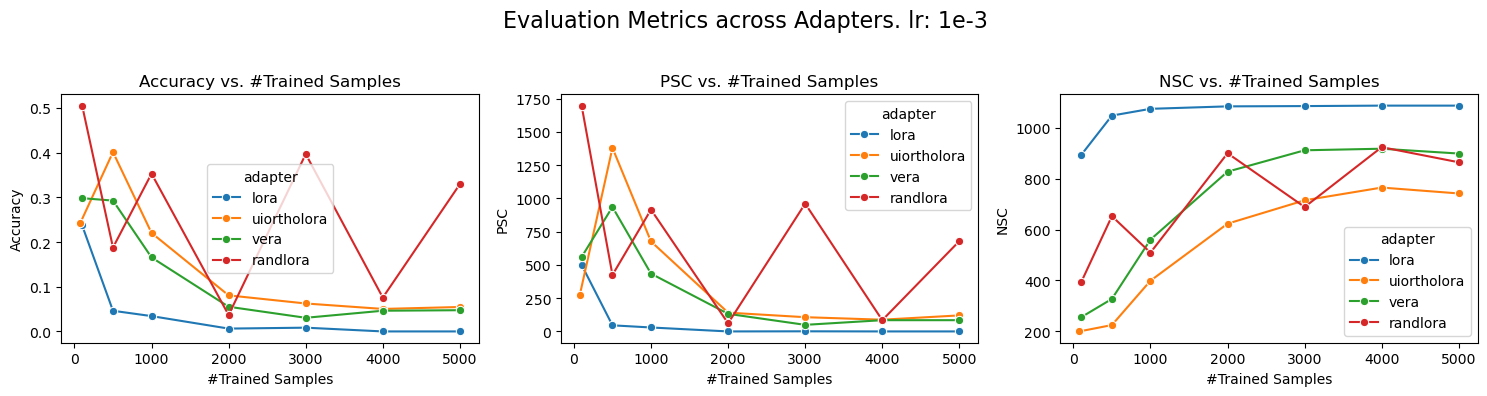

,adapter,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr100_lo...,100,0.237000,500.4,892.9,556,917
1,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr500_lo...,500,0.046200,45.9,1048.4,51,1076
2,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr1000_l...,1000,0.034300,29.7,1075.0,33,1103
3,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr2000_l...,2000,0.006350,0.0,1084.7,0,1113
4,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr3000_l...,3000,0.008400,0.9,1085.8,1,1114
5,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr4000_l...,4000,0.000000,0.0,1087.6,0,1116
6,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr5000_l...,5000,0.000000,0.0,1087.6,0,1116
7,uiortholora,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,77,0.242857,275.4,199.4,306,211
8,uiortholora,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,500,0.401000,1380.6,224.5,1534,233
9,uiortholora,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,1000,0.220300,676.8,398.8,752,415


In [43]:
evaluate_multiple_adapters_by_trainedN(
    df,
    adapters=adapters_lr1e_3,
    base_model_name=base_model_name,
    learning_rate="1e-3"
)

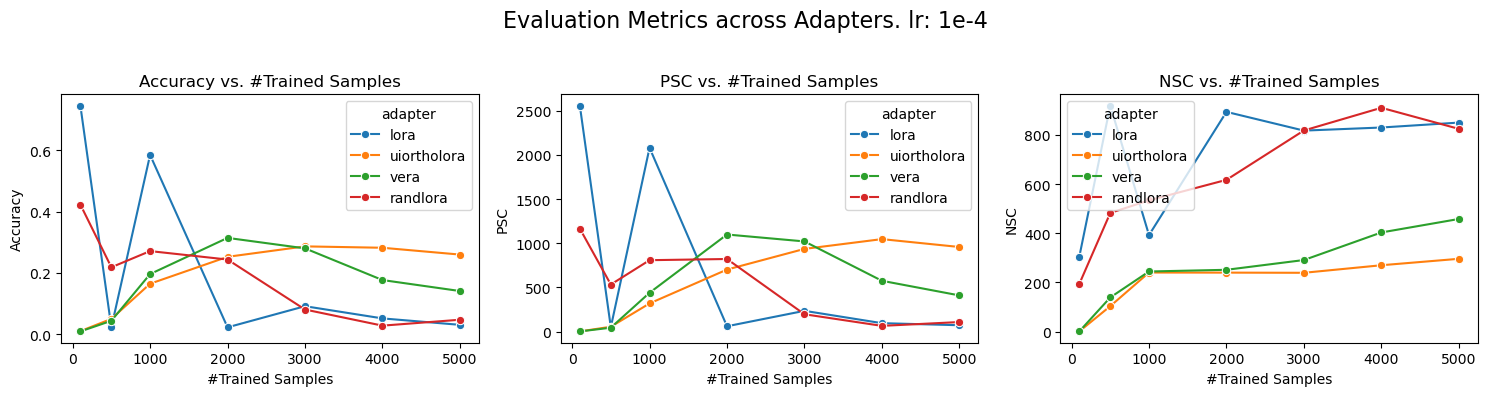

,adapter,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr100_lo...,100,0.746000,2557.8,304.6,2842,313
1,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr500_lo...,500,0.022000,49.5,919.0,55,946
2,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr1000_l...,1000,0.585000,2079.9,392.6,2311,403
3,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr2000_l...,2000,0.022350,60.3,893.6,67,920
4,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr3000_l...,3000,0.091333,234.9,817.4,261,842
5,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr4000_l...,4000,0.051525,95.4,830.0,106,855
6,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr5000_l...,5000,0.030520,72.0,850.0,80,878
7,uiortholora,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,100,0.010000,1.8,1.0,2,1
8,uiortholora,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,500,0.050000,54.9,103.7,61,110
9,uiortholora,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,1000,0.164700,318.6,240.4,354,252


In [44]:
evaluate_multiple_adapters_by_trainedN(
    df,
    adapters=adapters_lr1e_4,
    base_model_name=base_model_name,
    learning_rate="1e-4"
)


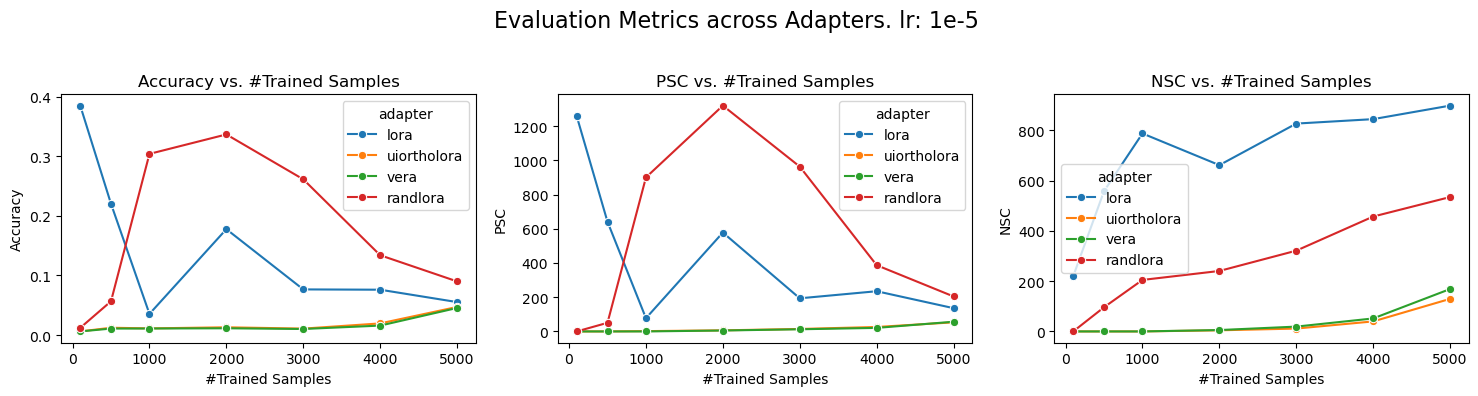

,adapter,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr100_lo...,100,0.385000,1257.3,220.0,1397,229
1,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr500_lo...,500,0.220200,640.8,558.3,712,577
2,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr1000_l...,1000,0.035400,77.4,788.1,86,813
3,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr2000_l...,2000,0.177650,577.8,662.0,642,682
4,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr3000_l...,3000,0.076533,193.5,827.4,215,852
5,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr4000_l...,4000,0.076025,234.9,845.1,261,871
6,lora,meta-llama_Llama-3.1-8B-Instruct_lora_tr5000_l...,5000,0.055260,135.9,898.9,151,925
7,uiortholora,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,100,0.006000,0.0,0.0,0,0
8,uiortholora,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,500,0.012200,0.0,0.0,0,0
9,uiortholora,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,1000,0.011100,1.8,0.0,2,0


In [45]:
evaluate_multiple_adapters_by_trainedN(
    df,
    adapters=adapters_lr1e_5,
    base_model_name=base_model_name,
    learning_rate="1e-5"
)


In [46]:
stop

NameError: name 'stop' is not defined

In [ ]:
# uiortholora_adapter_models = [
#         # "meta-llama_Llama-3.2-3B_uiortholora_tr100_uiortholora_s256_v64",
#         # "meta-llama_Llama-3.2-3B_uiortholora_tr500_uiortholora_s256_v64",
#         # "meta-llama_Llama-3.2-3B_uiortholora_tr1000_uiortholora_s256_v64",
#         # "meta-llama_Llama-3.2-3B_uiortholora_tr2000_uiortholora_s256_v64",
#         "meta-llama_Llama-3.2-3B_uiortholora_tr3000_uiortholora_s256_v64",
#         "meta-llama_Llama-3.2-3B_uiortholora_tr4000_uiortholora_s256_v64",
#         "meta-llama_Llama-3.2-3B_uiortholora_tr5000_uiortholora_s256_v64"
#     ]
# lora_adapter_models = [
#         # "meta-llama_Llama-3.2-3B_lora_tr100_lora_r3",
#         # "meta-llama_Llama-3.2-3B_lora_tr500_lora_r3",
#         # "meta-llama_Llama-3.2-3B_lora_tr1000_lora_r3",
#         # "meta-llama_Llama-3.2-3B_lora_tr2000_lora_r3",
#         "meta-llama_Llama-3.2-3B_lora_tr3000_lora_r3",
#         "meta-llama_Llama-3.2-3B_lora_tr4000_lora_r3",
#         "meta-llama_Llama-3.2-3B_lora_tr5000_lora_r3"
#     ]
# vera_adapter_models = [
#         "meta-llama_Llama-3.2-3B_vera_tr100_vera_r1024",
#         "meta-llama_Llama-3.2-3B_vera_tr500_vera_r1024",
#         "meta-llama_Llama-3.2-3B_vera_tr1000_vera_r1024",
#         "meta-llama_Llama-3.2-3B_vera_tr2000_vera_r1024"
# ]
# randlora_adapter_models = [
#         "meta-llama_Llama-3.2-3B_randlora_tr100_randlora_r512",
#         "meta-llama_Llama-3.2-3B_randlora_tr500_randlora_r512",
#         "meta-llama_Llama-3.2-3B_randlora_tr1000_randlora_r512",
#         "meta-llama_Llama-3.2-3B_randlora_tr2000_randlora_r512",
#         "meta-llama_Llama-3.2-3B_randlora_tr3000_randlora_r512",
#         "meta-llama_Llama-3.2-3B_randlora_tr4000_randlora_r512",
#         "meta-llama_Llama-3.2-3B_randlora_tr5000_randlora_r512"
# ]

base_model_name = "Llama-3.1-8B-Instruct"

Evaluating adapter family across runs: ['meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr100_uiortholora_s256_v64_lr1e-4', 'meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr500_uiortholora_s256_v64_lr1e-4', 'meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr1000_uiortholora_s256_v64_lr1e-4', 'meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr2000_uiortholora_s256_v64_lr1e-4', 'meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr3000_uiortholora_s256_v64_lr1e-4', 'meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr4000_uiortholora_s256_v64_lr1e-4', 'meta-llama_Llama-3.1-8B-Instruct_uiortholora_tr5000_uiortholora_s256_v64_lr1e-4']


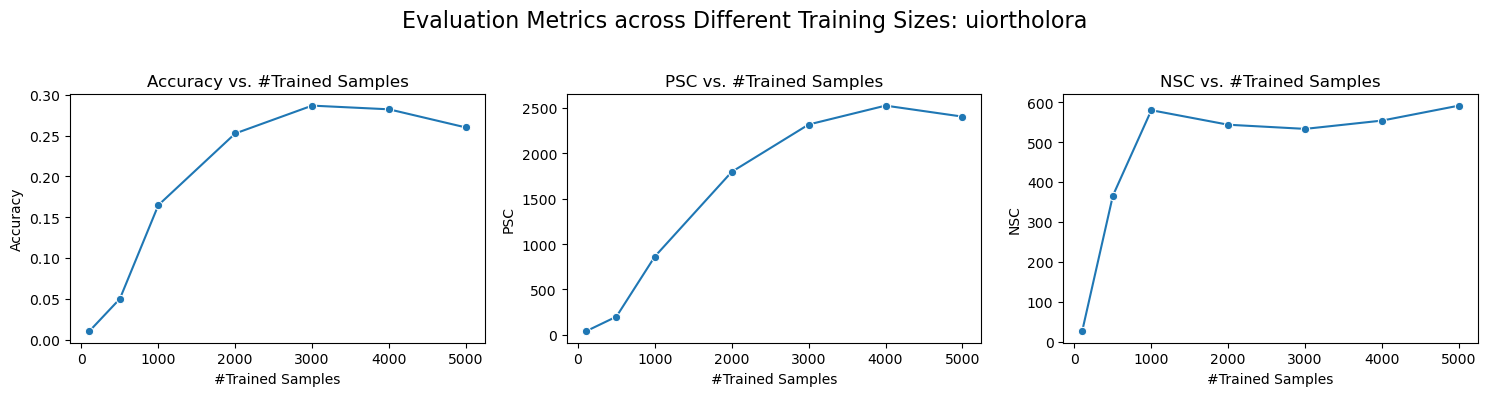

,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,100,0.010000,36.4,25.3,54,38
1,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,500,0.050000,199.2,365.6,263,473
2,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,1000,0.164700,862.2,579.8,1097,715
3,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,2000,0.252500,1795.4,543.4,2264,667
4,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,3000,0.286600,2317.3,533.0,2911,651
5,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,4000,0.282075,2525.6,553.8,3159,670
6,meta-llama_Llama-3.1-8B-Instruct_uiortholora_t...,5000,0.259840,2404.4,591.3,3018,709


In [ ]:
# print(f"Evaluating adapter family across runs: {uiortholora_adapter_models}")
evaluate_multiple_adapter_by_trainedN(df, uiortholora_adapter_models, "uiortholora", base_model_name)

Evaluating adapter family across runs: ['meta-llama_Llama-3.1-8B-Instruct_lora_tr100_lora_r3_lr1e-5', 'meta-llama_Llama-3.1-8B-Instruct_lora_tr500_lora_r3_lr1e-5', 'meta-llama_Llama-3.1-8B-Instruct_lora_tr1000_lora_r3_lr1e-5', 'meta-llama_Llama-3.1-8B-Instruct_lora_tr2000_lora_r3_lr1e-5', 'meta-llama_Llama-3.1-8B-Instruct_lora_tr3000_lora_r3_lr1e-5', 'meta-llama_Llama-3.1-8B-Instruct_lora_tr4000_lora_r3_lr1e-5', 'meta-llama_Llama-3.1-8B-Instruct_lora_tr5000_lora_r3_lr1e-5']


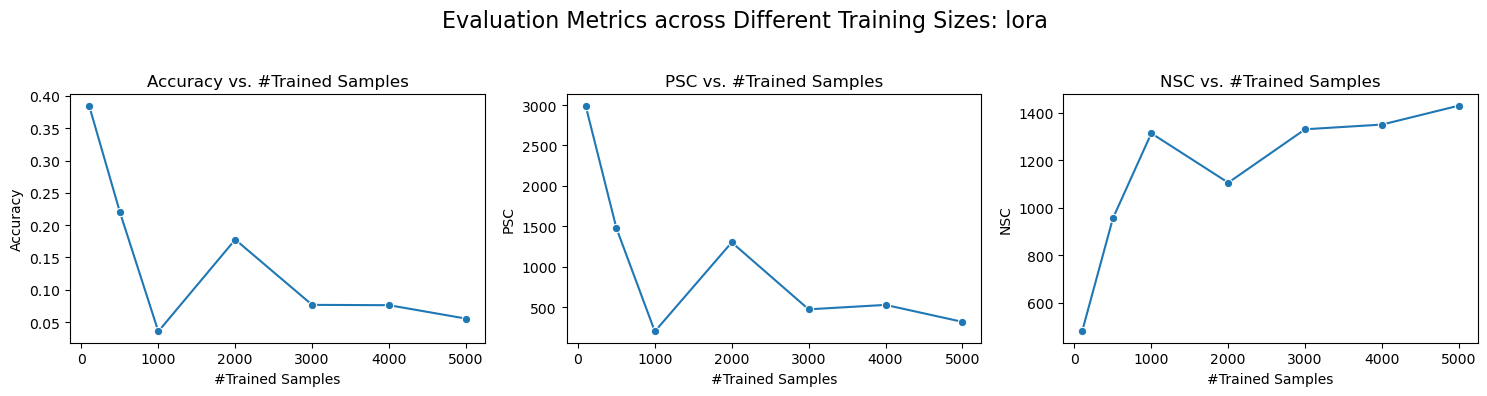

,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,meta-llama_Llama-3.1-8B-Instruct_lora_tr100_lo...,100,0.385000,2992.5,478.4,3734,581
1,meta-llama_Llama-3.1-8B-Instruct_lora_tr500_lo...,500,0.220200,1480.2,954.6,1835,1112
2,meta-llama_Llama-3.1-8B-Instruct_lora_tr1000_l...,1000,0.035400,203.1,1313.2,257,1519
3,meta-llama_Llama-3.1-8B-Instruct_lora_tr2000_l...,2000,0.177650,1303.3,1105.1,1613,1278
4,meta-llama_Llama-3.1-8B-Instruct_lora_tr3000_l...,3000,0.076533,476.1,1330.1,593,1526
5,meta-llama_Llama-3.1-8B-Instruct_lora_tr4000_l...,4000,0.076025,530.9,1349.9,658,1548
6,meta-llama_Llama-3.1-8B-Instruct_lora_tr5000_l...,5000,0.055260,321.3,1429.7,400,1636


In [ ]:
print(f"Evaluating adapter family across runs: {lora_adapter_models}")
evaluate_single_adapter_by_trainedN(df, lora_adapter_models, "lora", base_model_name)

In [ ]:
stop

NameError: name 'stop' is not defined

In [ ]:
# print(f"Evaluating adapter family across runs: {vera_adapter_models}")
# evaluate_single_adapter_by_trainedN(df, vera_adapter_models, "vera", base_model_name)

In [ ]:
print(f"Evaluating adapter family across runs: {randlora_adapter_models}")
evaluate_single_adapter_by_trainedN(df, randlora_adapter_models, "randlora", base_model_name)

Evaluating adapter family across runs: ['meta-llama_Llama-3.2-3B_randlora_tr100_randlora_r512', 'meta-llama_Llama-3.2-3B_randlora_tr500_randlora_r512', 'meta-llama_Llama-3.2-3B_randlora_tr1000_randlora_r512', 'meta-llama_Llama-3.2-3B_randlora_tr2000_randlora_r512', 'meta-llama_Llama-3.2-3B_randlora_tr3000_randlora_r512', 'meta-llama_Llama-3.2-3B_randlora_tr4000_randlora_r512', 'meta-llama_Llama-3.2-3B_randlora_tr5000_randlora_r512']


KeyError: "For model 'meta-llama_Llama-3.2-3B_randlora_tr3000_randlora_r512', missing columns: ['meta_llama_Llama_3_2_3B_randlora_tr3000_randlora_r512_score', 'meta_llama_Llama_3_2_3B_randlora_tr3000_randlora_r512_train']. Did you pass raw names? (e.g., '..._tr100')"

In [ ]:
stop

Evaluating adapter family across runs: ['meta-llama_Llama-3.2-3B_vera_tr100_vera_r1024', 'meta-llama_Llama-3.2-3B_vera_tr500_vera_r1024', 'meta-llama_Llama-3.2-3B_vera_tr1000_vera_r1024', 'meta-llama_Llama-3.2-3B_vera_tr2000_vera_r1024']


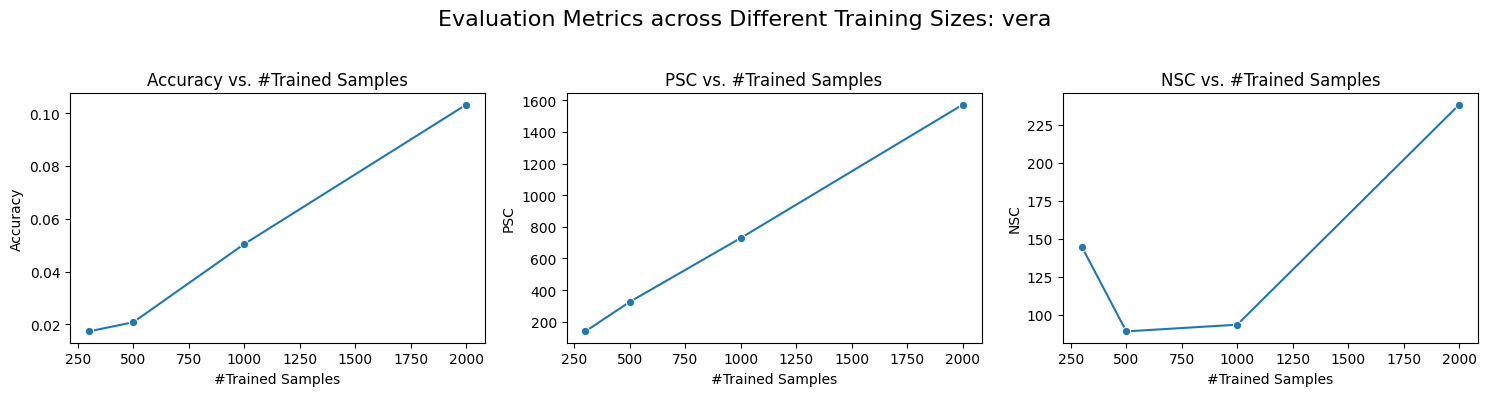

,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,meta-llama_Llama-3.2-3B_vera_tr100_vera_r1024,300,0.017333,138.2,144.6,212,213
1,meta-llama_Llama-3.2-3B_vera_tr500_vera_r1024,500,0.020800,325.2,89.0,472,133
2,meta-llama_Llama-3.2-3B_vera_tr1000_vera_r1024,1000,0.050400,729.0,93.4,989,134
3,meta-llama_Llama-3.2-3B_vera_tr2000_vera_r1024,2000,0.103200,1572.6,238.2,1965,317


In [ ]:
print(f"Evaluating adapter family across runs: {vera_adapter_models}")
evaluate_single_adapter_by_trainedN(df, vera_adapter_models, "vera", base_model_name)

Evaluating FT model 'meta-llama_Llama-3.2-3B_uiortholora_tr100_uiortholora_s256_v64' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_uiortholora_tr100_uiortholora_s256_v64
Baseline: Llama-3.2-3B
Trained samples: 100
Accuracy: 0.048
PSC: 477.000 (681 samples)
NSC: 108.400 (158 samples)


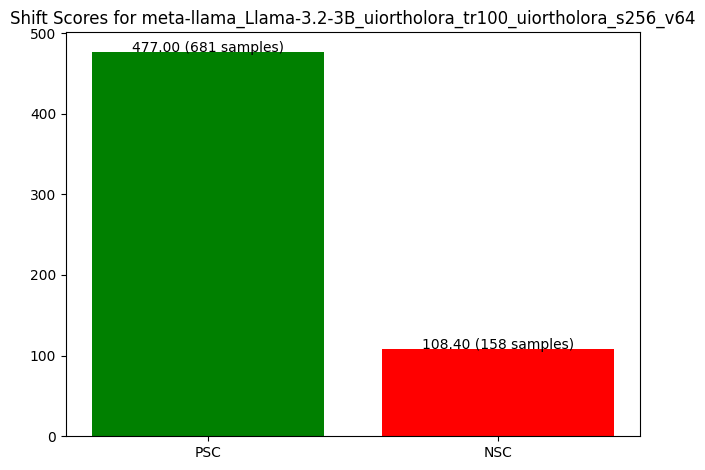

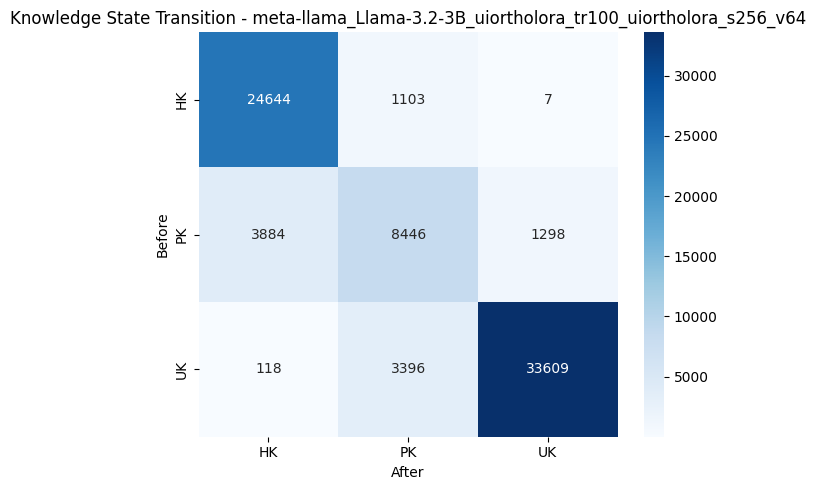

Evaluating FT model 'meta-llama_Llama-3.2-3B_uiortholora_tr500_uiortholora_s256_v64' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_uiortholora_tr500_uiortholora_s256_v64
Baseline: Llama-3.2-3B
Trained samples: 500
Accuracy: 0.142
PSC: 2014.800 (2420 samples)
NSC: 849.000 (1027 samples)


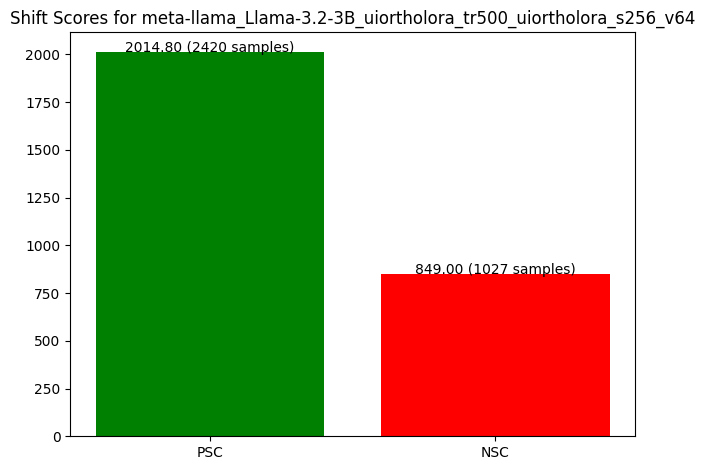

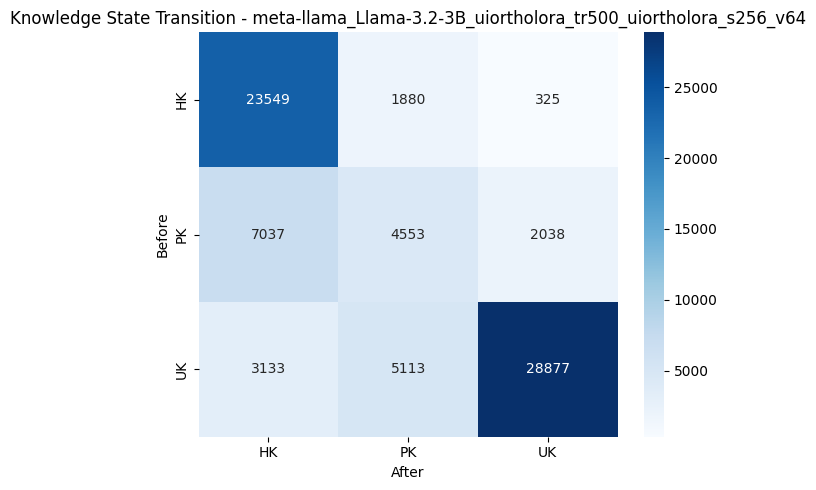

Evaluating FT model 'meta-llama_Llama-3.2-3B_uiortholora_tr1000_uiortholora_s256_v64' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_uiortholora_tr1000_uiortholora_s256_v64
Baseline: Llama-3.2-3B
Trained samples: 1000
Accuracy: 0.191
PSC: 2425.800 (2833 samples)
NSC: 3502.800 (3868 samples)


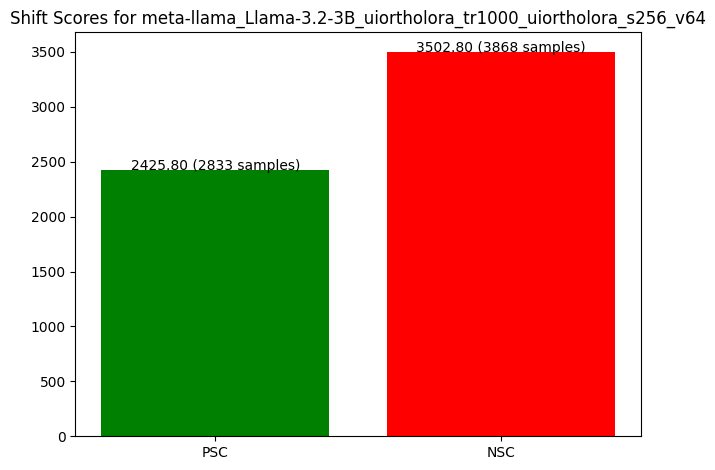

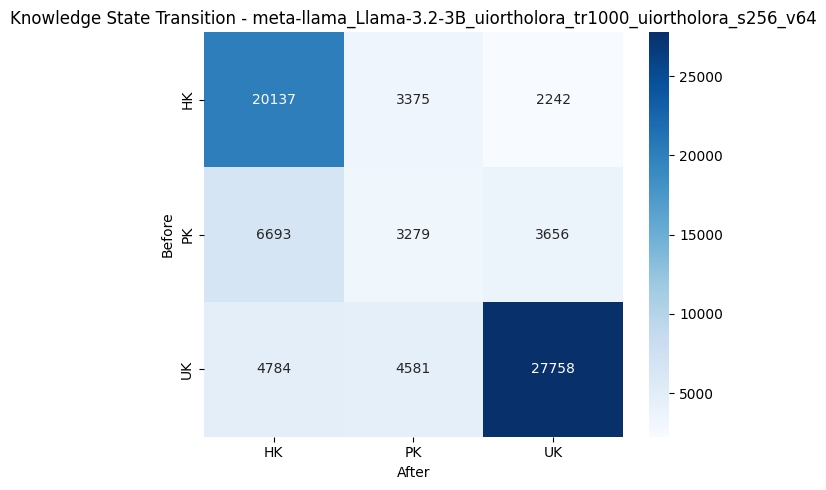

Evaluating FT model 'meta-llama_Llama-3.2-3B_uiortholora_tr2000_uiortholora_s256_v64' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_uiortholora_tr2000_uiortholora_s256_v64
Baseline: Llama-3.2-3B
Trained samples: 2000
Accuracy: 0.224
PSC: 2781.600 (3215 samples)
NSC: 3865.200 (4195 samples)


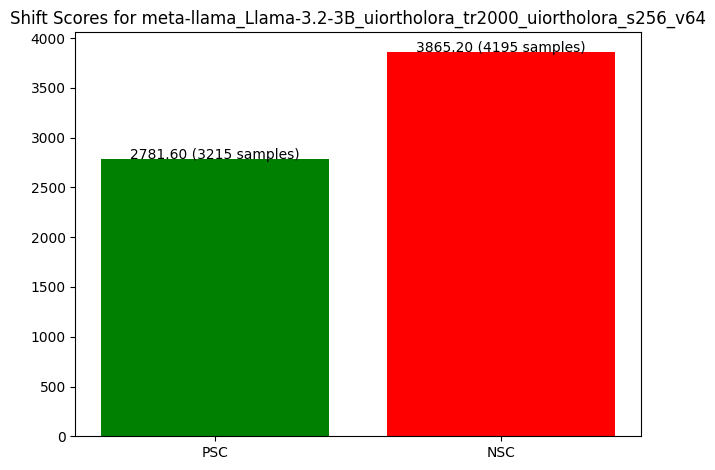

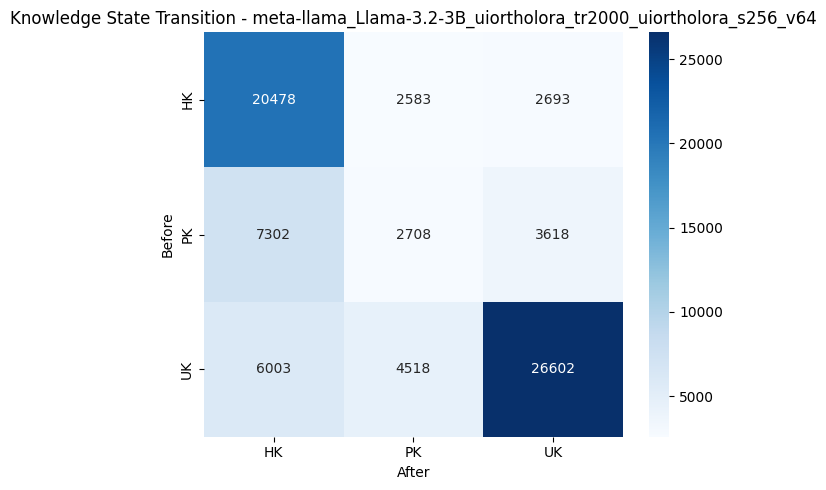

In [ ]:
if ft_model_names and df["base_model_id"].notna().any():
    for ft_model_name in uiortholora_adapter_models:
        base_model_name = df["base_model_id"].dropna().unique()[0]
        print(f"Evaluating FT model '{ft_model_name}' vs baseline '{base_model_name}'")
        evaluate_single_run(df, ft_model_name, base_model_name)

Evaluating FT model 'meta-llama_Llama-3.2-3B_lora_tr100_lora_r3' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_lora_tr100_lora_r3
Baseline: Llama-3.2-3B
Trained samples: 100
Accuracy: 0.066
PSC: 562.800 (797 samples)
NSC: 90.000 (133 samples)


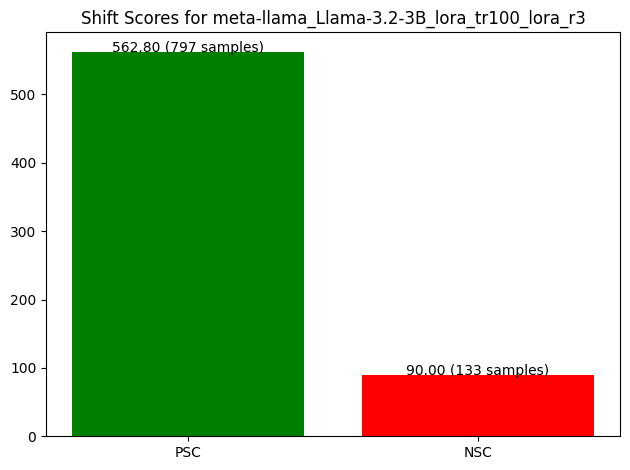

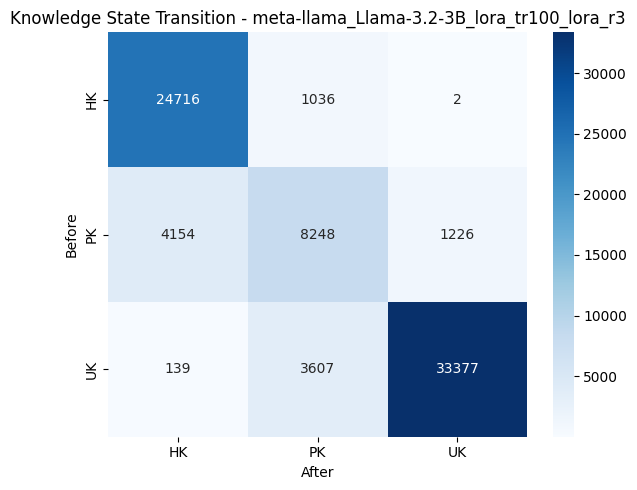

Evaluating FT model 'meta-llama_Llama-3.2-3B_lora_tr500_lora_r3' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_lora_tr500_lora_r3
Baseline: Llama-3.2-3B
Trained samples: 500
Accuracy: 0.185
PSC: 2641.600 (3055 samples)
NSC: 4092.800 (4441 samples)


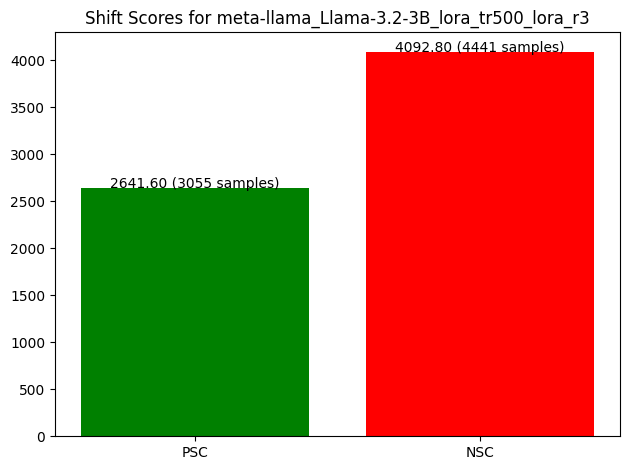

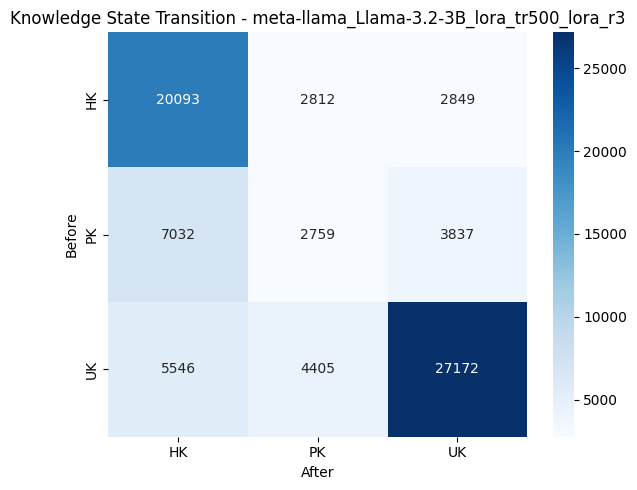

Evaluating FT model 'meta-llama_Llama-3.2-3B_lora_tr1000_lora_r3' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_lora_tr1000_lora_r3
Baseline: Llama-3.2-3B
Trained samples: 1000
Accuracy: 0.252
PSC: 2944.200 (3384 samples)
NSC: 3936.600 (4272 samples)


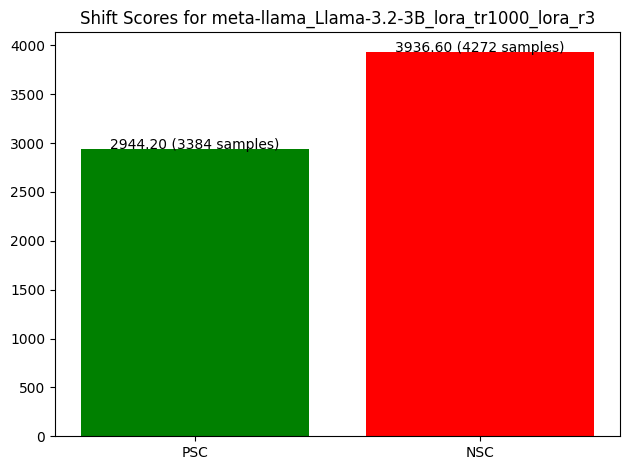

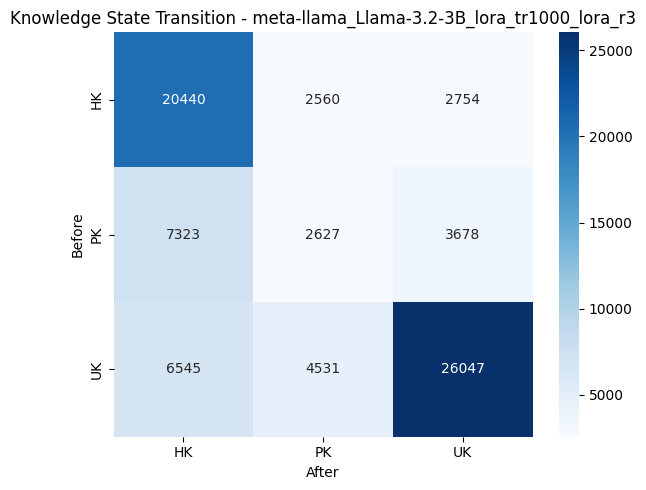

Evaluating FT model 'meta-llama_Llama-3.2-3B_lora_tr2000_lora_r3' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_lora_tr2000_lora_r3
Baseline: Llama-3.2-3B
Trained samples: 2000
Accuracy: 0.040
PSC: 345.800 (409 samples)
NSC: 22882.800 (23778 samples)


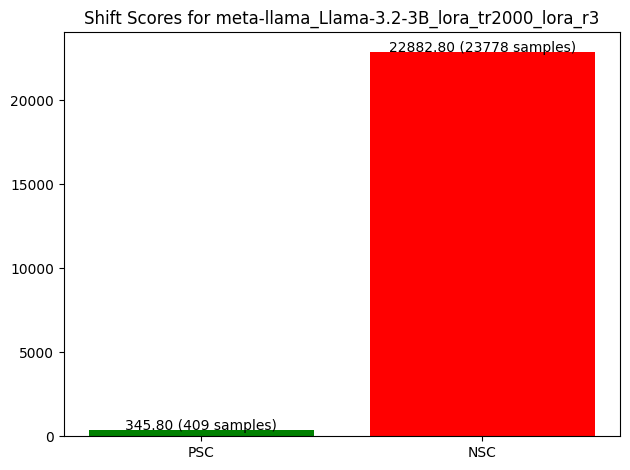

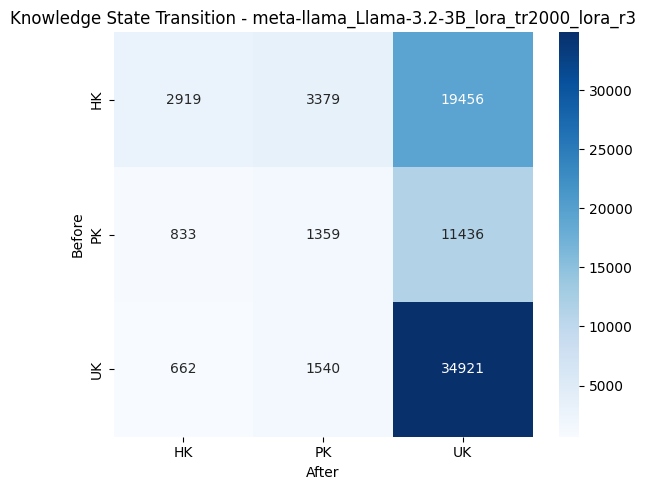

In [ ]:
if ft_model_names and df["base_model_id"].notna().any():
    for ft_model_name in lora_adapter_models:
        base_model_name = df["base_model_id"].dropna().unique()[0]
        print(f"Evaluating FT model '{ft_model_name}' vs baseline '{base_model_name}'")
        evaluate_single_run(df, ft_model_name, base_model_name)

Evaluating FT model 'meta-llama_Llama-3.2-3B_randlora_tr100_randlora_r512' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_randlora_tr100_randlora_r512
Baseline: Llama-3.2-3B
Trained samples: 100
Accuracy: 0.024
PSC: 112.800 (172 samples)
NSC: 158.800 (235 samples)


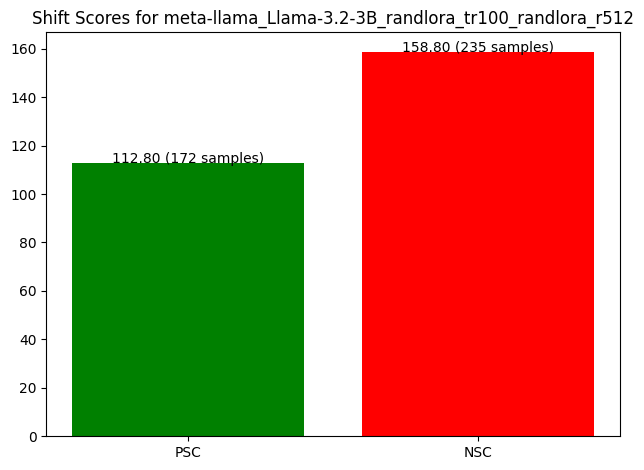

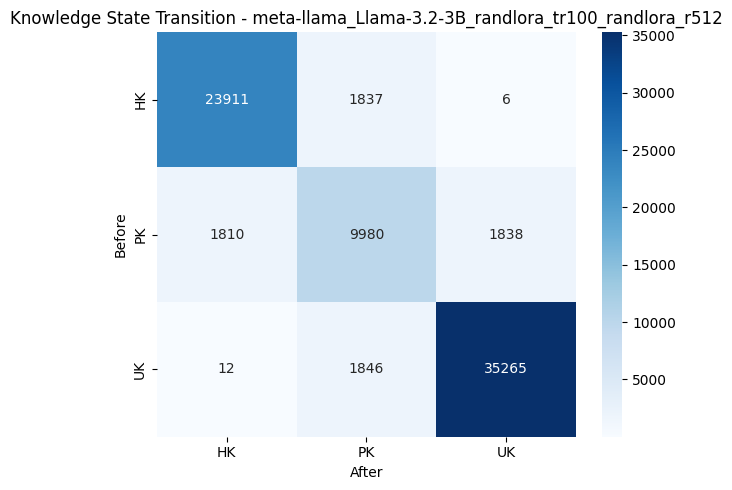

Evaluating FT model 'meta-llama_Llama-3.2-3B_randlora_tr500_randlora_r512' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_randlora_tr500_randlora_r512
Baseline: Llama-3.2-3B
Trained samples: 500
Accuracy: 0.020
PSC: 210.600 (325 samples)
NSC: 129.200 (193 samples)


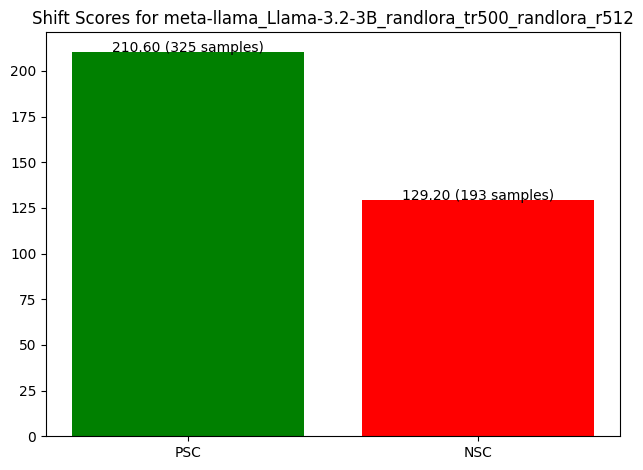

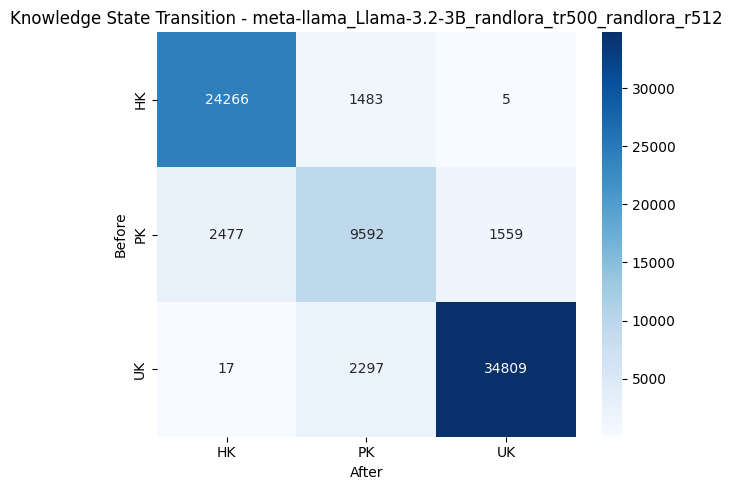

Evaluating FT model 'meta-llama_Llama-3.2-3B_randlora_tr1000_randlora_r512' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_randlora_tr1000_randlora_r512
Baseline: Llama-3.2-3B
Trained samples: 1000
Accuracy: 0.059
PSC: 900.800 (1190 samples)
NSC: 113.800 (160 samples)


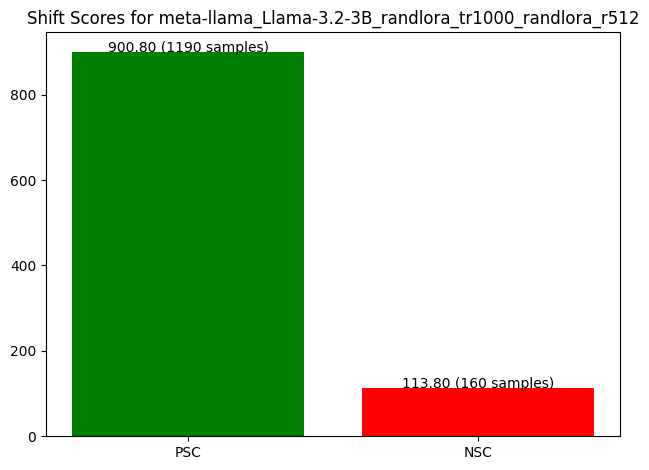

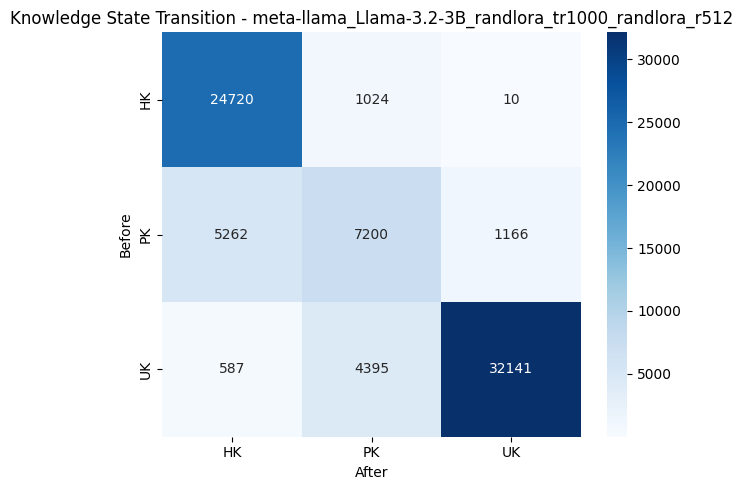

Evaluating FT model 'meta-llama_Llama-3.2-3B_randlora_tr2000_randlora_r512' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_randlora_tr2000_randlora_r512
Baseline: Llama-3.2-3B
Trained samples: 2000
Accuracy: 0.167
PSC: 2268.800 (2692 samples)
NSC: 1158.200 (1357 samples)


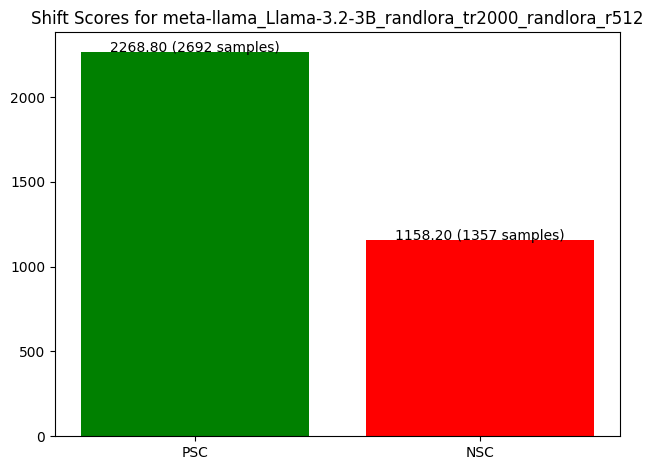

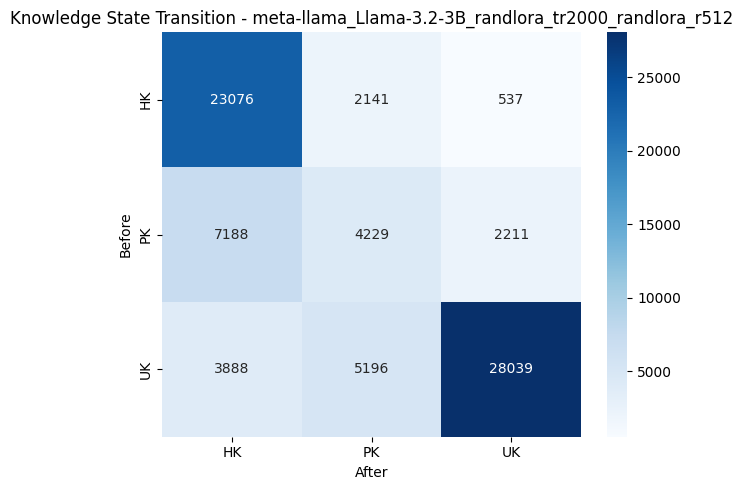

In [ ]:
if ft_model_names and df["base_model_id"].notna().any():
    for ft_model_name in randlora_adapter_models:
        base_model_name = df["base_model_id"].dropna().unique()[0]
        print(f"Evaluating FT model '{ft_model_name}' vs baseline '{base_model_name}'")
        evaluate_single_run(df, ft_model_name, base_model_name)